In [36]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u

from prism.data import Spectrum
import prism.modeling.models as models
import prism.modeling.fitting as fitting
from prism.modeling.fitting import tie
import prism.modeling.display # importing the display module enables the model display features

plt.rcParams['axes.xmargin'] = 0

In [37]:
filename = 'data/agnspec.txt'

# (Optional) Set the source coordinates and redshift
dec, ra = -25.12345, 13.12345
redshift = 0.0622

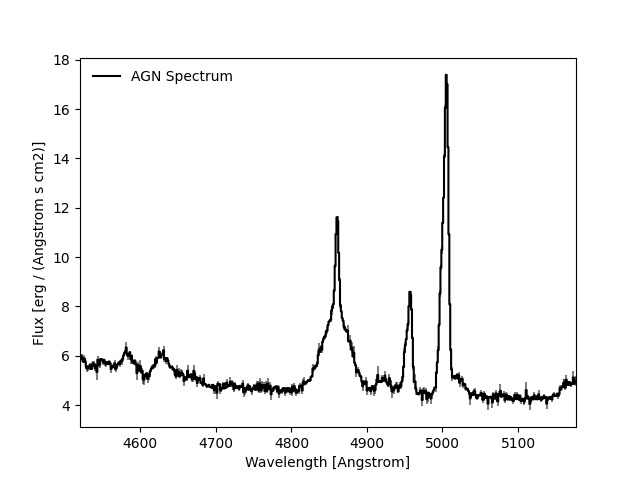

In [38]:
spec = Spectrum.from_txt(filename=filename,
                         ra=ra,
                         dec=dec,
                         z=redshift,
                         wave_unit=u.AA,
                         unit=1e-15 * u.erg / (u.s * u.cm**2 * u.AA),
                         name='AGN Spectrum')

# # (Example) Mask a region
# wmask = (spec.wave <= 5800) | (spec.wave >= 5980)
# spec.crop(wmask=wmask)

# (Example) Crop a portion of the spectrum
wbounds = (4800., 5500.) # Å
spec.crop(wbounds=wbounds)

# Apply Galactic extinction correction
spec.deredden()

# (Optional) Apply redshift correction to rest frame
spec.zcorrect()

spec.plot_spectrum() 

In [39]:
# (Optional) Copy locally the CSV file containing the line list, and set up the local line database.
models.setup_local_lines(wmin=np.min(spec.wave), wmax=np.max(spec.wave), overwrite=True)

# # If you want to blindly proceed with the default line list without inspecting it, you can use models.set_wavelength_range()
# # This will just filter the lines to those that fall within the wavelength range of interest.
# models.set_wavelength_range(wmin=np.min(spec.wave), wmax=np.max(spec.wave))

# NOTE: If you decide to work in the observed frame, you should remember to set the line database to the rest frame, i.e. models.set_wavelength_range(wmin=np.min(spec.wave)/(1+redshift), wmax=np.max(spec.wave)/(1+redshift))

Wavelength range set to: [4520.099792882696, 5176.755789870081]


In [40]:
# Line Models support instumental broadening. This can be set to either a constant value (in km/s) or a 2D array with wavelength and FWHM values (in km/s).
# The latter is useful when the instrumental resolution varies significantly across the wavelength range of interest.
# For the sake of simplicity we will use a constant value here, but I leave a snippet below to show how to set up a wavelength-dependent instrumental broadening based on the MUSE instrumental response.

instfwhm = 0. # km/s


# # Set wavelength-dependent instrumental broadening based on the MUSE instrumental response
# from astropy.constants import c
# c_kms = c.to('km/s').value

# # Instrumental Response of MUSE from the MUSE User Manual
# resp_lambda = np.array([4650.0, 5000.0, 5500.0, 6000.0, 6500.0, 7000.0, 7500.0, 8000.0, 8500.0, 9000.0, 9350.0])
# resp_R = np.array([1609, 1750, 1978, 2227, 2484, 2737, 2975, 3183, 3350, 3465, 3506])

# wave_rest = resp_lambda * (1.0 + redshift) # Null the zcorrection for instrumental effects. Not needed if you are working in the observed frame.
# fwhm_km_s = c_kms / resp_R

# instfwhm = np.array([wave_rest, fwhm_km_s]).T

In [41]:
# Setup the model

# Continuum
bknpower = models.BrokenPowerlaw(
    name='bknpower',
    x_ref=5450,
    amplitude=np.median(spec.flux),
    index1=-2.0,
    index2=0.0,
    bounds={
        'x_ref': (5100, 5710),
        'amplitude': (1.5, 5.0),
        'index1': (-3.0, 0.0),
        'index2': (-1.0, 1.5),
    }
)

# Broad Line Region (BLR)
blr = models.agn.blr(
    name='blr',
    amplitude=10,
    offset=-360,
    fwhm=3727,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 1000),
        'offset': (-1000, 1000),
        'fwhm': (500, 8000),
    },
)

# Narrow Line Region (NLR)
nlr = models.agn.nlr(
    name='nlr',
    amplitude=1,
    offset=0,
    fwhm=500,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-300, 300),
        'fwhm': (0, 800),
    }
)

# Let's add Hydrogen and Helium lines tied to the NLR component. By default they are kept separate.
hhe_nlr = models.GaussianLines.from_csv(
    name='hhe_nlr',
    csv_files=['hydrogen.csv', 'helium.csv'],
    amplitude=1,
    offset=0,
    fwhm=500,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-300, 300),
        'fwhm': (0, 800),
    }
)
# Link the kinematics of the Hydrogen and Helium lines to those of the NLR component.
hhe_nlr.offset.tied = tie("nlr", lambda m: m.offset)
hhe_nlr.fwhm.tied = tie("nlr", lambda m: m.fwhm)

# OIII outflow
oiii_out = models.GaussianLines.from_csv(
    name='oiii',
    csv_files=['oiii.csv'],
    amplitude=1,
    offset=-560,
    fwhm=850,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-1000, 750),
        'fwhm': (50, 1500),
    }
)

# FeII Model
fe = models.agn.fe(
    name='fe',
    offset=0,
    fwhm=1200,
    instfwhm=instfwhm,
    bounds={
        'amplitude': (0, 100),
        'offset': (-3000, 3000),
        'fwhm': (800, 3000),
    }
)


# Combine all components
model = bknpower + blr + nlr + hhe_nlr + oiii_out + fe

In [42]:
from prism.modeling import instrument

# Create the wavelength grid in the observer frame (not redshift corrected)
# Standard grid for agnspec.txt: 4700 to 7560 Angstrom
wave_obs = np.arange(4700, 7561.25, 1.25)

# Define the FWHM gradient from 80 to 120 km/s
fwhm_kms = np.linspace(80, 120, len(wave_obs))

# Convert FWHM from km/s to Angstrom: FWHM_ang = (v / c) * lambda
from astropy.constants import c
c_kms = c.to('km/s').value
fwhm_ang = (fwhm_kms / c_kms) * wave_obs

# Calculate Gaussian sigma values
sigmas = fwhm_ang / (2 * np.sqrt(2 * np.log(2)))

# Build the sparse response matrix
# Using the internal helper from InstrumentResponse
matrix = instrument.InstrumentResponse._build_sparse_gaussian_matrix(wave_obs, sigmas)

# Create the InstrumentResponse instance (temporary, not saved to disk)
custom_ir = instrument.InstrumentResponse(wave_obs, matrix)

# Apply to the model using SpectralResponse (passing the instance directly)
# This keeps it temporary for this session and does not write to the archive.
lsf = instrument.SpectralResponse(
    instrument=custom_ir,
    wave=spec.wave,
    z=spec.z,
    name='lsf',
)
model = model | lsf # Apply the response


In [43]:
model

<CompoundModel((bknpower + blr + nlr + hhe_nlr + oiii + fe) | lsf; amplitude_0=4.88445, x_ref_0=5450, index1_0=-2, index2_0=0, ...)>

In [44]:
from astropy.modeling.fitting import TRFLSQFitter
fitter = TRFLSQFitter()
fitter.max_evaluations = 5000

# fitter = fitting.ScipyTRF(jac='2-point')
# fitter = fitting.SherpaLM()

model = fitter(model=model, x=spec.wave, y=spec.flux, yerr=spec.err, inplace=True)

In [45]:
# Compute chi-squared
residuals = spec.flux - model(spec.wave)
chi_squared = np.sum((residuals / spec.err) ** 2)

print(f"Chi-squared: {chi_squared:.2f}")

Chi-squared: 384904.85


In [46]:
fitter.fit_info

     message: `xtol` termination condition is satisfied.
     success: True
      status: 3
         fun: [-1.078e+00 -2.913e+00 ... -1.370e+00 -1.400e+00]
           x: [ 3.738e+00  5.601e+03 ... -8.253e+01  1.537e+03]
        cost: 192452.42722564202
         jac: [[ 1.005e+01  4.389e-03 ... -2.698e-03  1.669e-03]
               [ 1.067e+01  4.661e-03 ... -1.362e-03  2.060e-03]
               ...
               [ 6.665e+00  2.911e-03 ...  5.555e-03  1.710e-03]
               [ 5.285e+00  2.309e-03 ...  4.627e-03  1.571e-03]]
        grad: [ 1.796e+04  7.844e+00 ...  4.330e+01 -1.832e+01]
  optimality: 522695.2210322438
 active_mask: [0 0 ... 0 0]
        nfev: 337
        njev: 337
   param_cov: [[ 2.567e-05  1.121e-08 ... -8.524e-04 -2.045e-03]
               [ 1.121e-08  4.898e-12 ... -3.723e-07 -8.935e-07]
               ...
               [-8.524e-04 -3.723e-07 ...  3.085e+00  5.944e-01]
               [-2.045e-03 -8.935e-07 ...  5.944e-01  4.626e+00]]
       nfree: 25
       nda

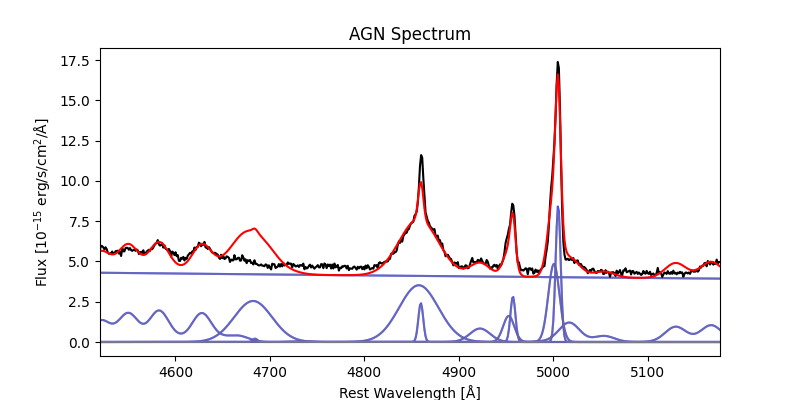

In [48]:
plt.figure(figsize=(8, 4))

comps = models.get_components(model, deconvolve=False)
for name in comps.names:
    plt.plot(spec.wave, comps[name](spec.wave), label=name)

plt.plot(spec.wave, spec.flux, label='Data', color='black')
plt.plot(spec.wave, model(spec.wave), label='Model', color='red')
plt.xlabel('Rest Wavelength [Å]')
plt.ylabel('Flux [10$^{-15}$ erg/s/cm$^2$/Å]')

# plt.ylim(bottom=0.1)
# plt.yscale('log')

plt.title(spec.name)

plt.show()